<h1><center>Machine Learning Project - AVAZU<center></h1>


In [3]:
import sys
from zipfile import ZipFile
import os.path as op
try:
    from urllib.request import urlretrieve
except ImportError:  # Python 2 compat
    from urllib import urlretrieve

AVAZU_URL = "https://bianchi.wp.imt.fr/files/2019/05/train-1000000.zip"
AVAZU_FILENAME = AVAZU_URL.rsplit('/', 1)[1]


if not op.exists(AVAZU_FILENAME):
    print('Downloading %s to %s...' % (AVAZU_URL, AVAZU_FILENAME))
    urlretrieve(AVAZU_URL, AVAZU_FILENAME)
    ZipFile(AVAZU_FILENAME).extractall('.')

In [4]:
ZipFile(AVAZU_FILENAME).extractall('.')

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
%matplotlib inline

Data description here: https://www.kaggle.com/c/avazu-ctr-prediction/data  


In [6]:
df = pd.read_csv('train-1000000')

## Work assignment

1.   Perform Exploratory Data Analysis (EDA)
2.   Predict the probability that an ad is clicked, based on the features.
3.   Evaluate the performance of your method.

## Work evaluation

Your work will be evaluated based on:

*   The interest of the EDA (4 points)
*   The quality of the comments/remarks throughout the notebook (4 points)
*   The feature engineering (5 points)
*   The efforts made in trying several predictors and tuning them (5 points)
*   The relevance of the performance criteria used to conclude (2 points)
*   BONUS (+1pt) : Register to the AVAZU challenge in Kaggle. What is your rank?

You may find the following script useful to convert the raw time stamp into a more useable feature. For instance, you may generate new pandas series using the code:

```
df['hour'].apply(lambda x:datesplit(x).weekday())
df['hour'].apply(lambda x:datesplit(x).hour)
```



In [60]:
import datetime
def datesplit(originalDate):
    originalDate = str(originalDate)

    year = int("20" + originalDate[0:2])
    month = int(originalDate[2:4])
    day = int(originalDate[4:6])
    hour = int(originalDate[6:8])

    return datetime.datetime(year, month, day, hour)

# Example :
datesplit(14102915).weekday(), datesplit(14102915).hour

(2, 15)

## 1. Exploratory Data Analysis

Before modelling, we explore the data to understand its size, the target, the temporal
dimension, and the (mostly anonymised, high-cardinality categorical) features. Every code
cell is followed by a short remark, since the clarity of the analysis is what matters most.

In [61]:
# --- High-level overview of the dataset ---
print("Dataset shape (rows, columns):", df.shape)                 # number of impressions and columns
print("Overall click-through rate (CTR):", round(df['click'].mean(), 4))  # fraction of impressions clicked
print("Total missing values in the frame:", int(df.isna().sum().sum()))   # NaNs across all columns
df.head()                                                          # peek at the first rows

Dataset shape (rows, columns): (1000000, 24)
Overall click-through rate (CTR): 0.17
Total missing values in the frame: 0


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,3.983206e+18,0,14102915,1005,1,e151e245,7e091613,f028772b,ecad2386,7801e8d9,...,1,2,4687,320,50,423,2,39,100148,32
1,7.756884e+18,0,14103007,1002,0,cb809abf,74acf31a,50e219e0,ecad2386,7801e8d9,...,0,0,17894,320,50,2039,2,39,100077,32
2,6.941774e+17,0,14102711,1005,0,85f751fd,c4e18dd6,50e219e0,e9739828,df32afa9,...,1,0,22684,320,50,2619,1,163,100055,71
3,2.664154e+18,1,14102903,1005,0,85f751fd,c4e18dd6,50e219e0,a5184c22,b8d325c3,...,1,0,23222,320,50,2676,0,35,100176,221
4,1.480510e+19,0,14102902,1005,1,791b5571,fd13bc73,f028772b,ecad2386,7801e8d9,...,1,0,8330,320,50,761,3,175,100081,23


**Remark.** We have **1,000,000 impressions** and 24 columns, with an overall **CTR ≈ 17%**.
Pandas reports *no* missing values — but we will see this is misleading: missingness in this dataset
is hidden inside *placeholder hash values* rather than `NaN`.

In [62]:
# --- Data types and cardinality (number of distinct values) per column ---
summary = pd.DataFrame({'dtype': df.dtypes,                        # type of each column
                        'n_unique': df.nunique()})                 # distinct values per column
summary.sort_values('n_unique', ascending=False)                  # most diverse columns first

,dtype,n_unique
id,float64,1000000
device_ip,object,555248
device_id,object,150501
device_model,object,5168
app_id,object,3157
site_domain,object,2871
site_id,object,2651
C14,int64,2243
C17,int64,420
hour,int64,240


**Remark.** `id` is unique per row (pure identifier → we drop it). A handful of features are
extremely high-cardinality — `device_ip` (~555k), `device_id` (~150k), `device_model`, `app_id`,
`site_id/site_domain`, `C14` — so classic **one-hot encoding is impossible** (it would create
hundreds of thousands of columns). Only a few features (`C1`, `banner_pos`, `device_type`,
`device_conn_type`, `C15/16/18`, the categories) are genuinely low-cardinality. This dictates the
whole feature-engineering strategy below: hashing, frequency encoding and target encoding.

{0: 830029, 1: 169971}


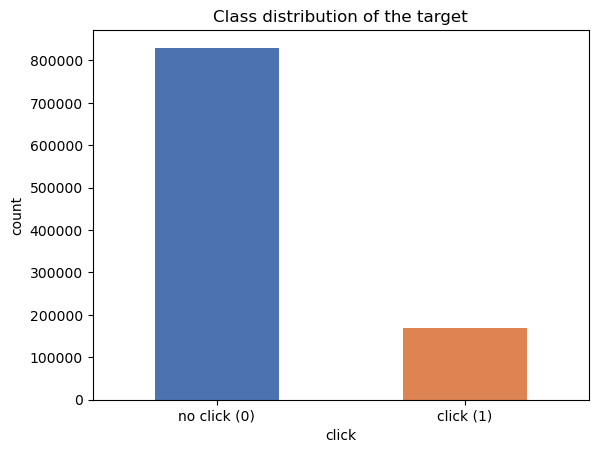

In [63]:
# --- Target distribution (class imbalance) ---
counts = df['click'].value_counts()                               # counts of 0 (no click) and 1 (click)
print(counts.to_dict())
ax = counts.sort_index().plot(kind='bar', color=['#4C72B0', '#DD8452'])
ax.set_xticklabels(['no click (0)', 'click (1)'], rotation=0)
ax.set_ylabel('count'); ax.set_title('Class distribution of the target'); plt.show()

**Remark.** About **17% positives**: imbalanced, though not extreme. A trivial 'always predict
no-click' classifier would already reach ~83% accuracy, which is why **accuracy is a useless metric
here**. We will score models with probability metrics (LogLoss and AUC).

In [64]:
# --- Decode the raw 'hour' integer (format YYMMDDHH) into usable time features ---
# pd.to_datetime is the vectorised equivalent of the provided datesplit() helper (much faster on 1e6 rows).
df['timestamp']   = pd.to_datetime(df['hour'].astype(str), format='%y%m%d%H')  # full datetime
df['hour_of_day'] = df['timestamp'].dt.hour                       # 0..23
df['day_of_week'] = df['timestamp'].dt.weekday                    # Mon=0 .. Sun=6
df['day']         = df['timestamp'].dt.day                        # calendar day (21..30)
print("Date range:", df['timestamp'].min(), "->", df['timestamp'].max())
print("Distinct days:", sorted(df['day'].unique()))

Date range: 2014-10-21 00:00:00 -> 2014-10-30 23:00:00
Distinct days: [np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30)]


**Remark.** The data spans **10 consecutive days (21–30 Oct 2014)**. Time is the only naturally
ordered feature, and it lets us build a *realistic* validation scheme (predict a future day) later on.

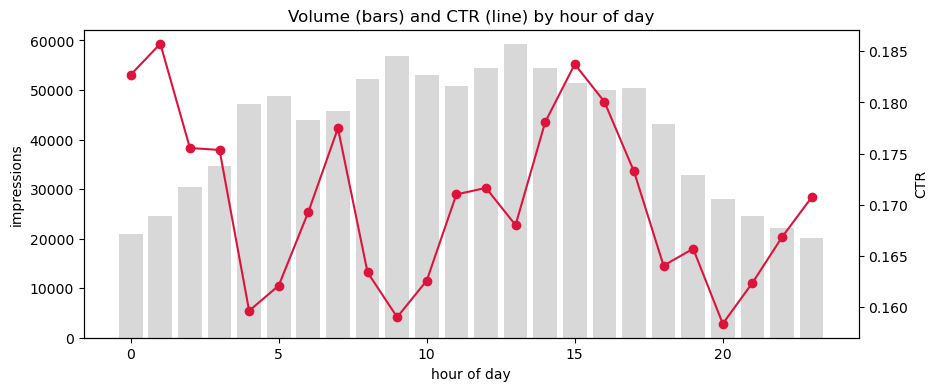

In [65]:
# --- Traffic volume and CTR by hour of day ---
fig, ax1 = plt.subplots(figsize=(10,4))
vol = df.groupby('hour_of_day').size()                            # impressions per hour
ctr = df.groupby('hour_of_day')['click'].mean()                   # CTR per hour
ax1.bar(vol.index, vol.values, alpha=0.3, color='gray'); ax1.set_ylabel('impressions')
ax2 = ax1.twinx(); ax2.plot(ctr.index, ctr.values, 'o-', color='crimson'); ax2.set_ylabel('CTR')
ax1.set_xlabel('hour of day'); plt.title('Volume (bars) and CTR (line) by hour of day'); plt.show()

**Remark.** Traffic follows a clear **diurnal cycle** and CTR fluctuates by a few points across the
day. The effect is modest but real, so `hour_of_day` is a useful (weak) feature.

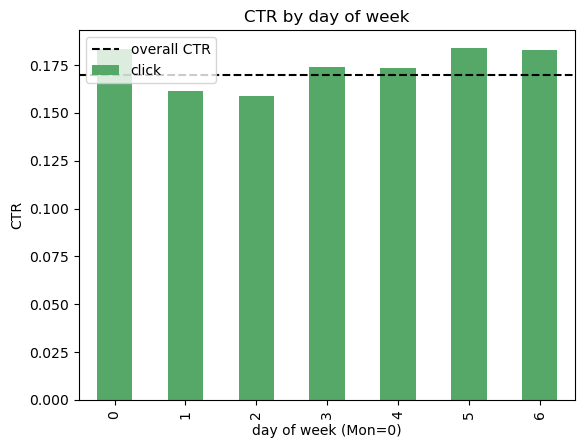

In [66]:
# --- CTR by day of week ---
ctr_dow = df.groupby('day_of_week')['click'].mean()
ax = ctr_dow.plot(kind='bar', color='#55A868')
ax.axhline(df['click'].mean(), color='k', ls='--', label='overall CTR')
ax.set_ylabel('CTR'); ax.set_xlabel('day of week (Mon=0)'); ax.legend()
plt.title('CTR by day of week'); plt.show()

**Remark.** Weekends show slightly higher CTR than mid-week. With only 10 days the weekday signal
is limited, but it is cheap to include.

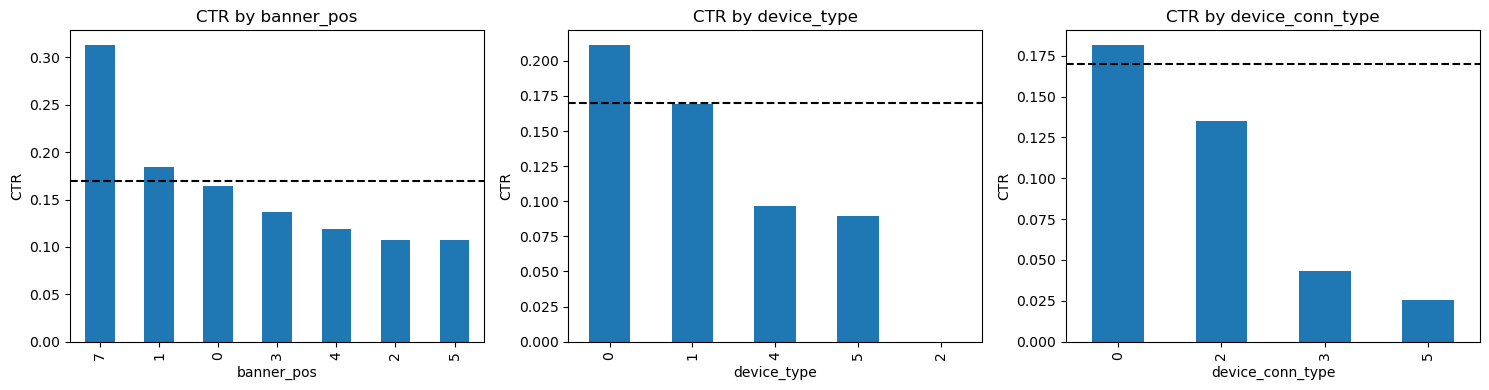

In [67]:
# --- CTR across several low-cardinality context features ---
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, ['banner_pos', 'device_type', 'device_conn_type']):
    g = df.groupby(col)['click'].mean().sort_values(ascending=False)   # CTR per category
    g.plot(kind='bar', ax=ax); ax.axhline(df['click'].mean(), color='k', ls='--')
    ax.set_title('CTR by ' + col); ax.set_ylabel('CTR')
plt.tight_layout(); plt.show()

**Remark.** These low-cardinality context features clearly **segment CTR**: some banner positions
convert far better than others, and device type / connection type (e.g. wifi vs cellular) separate
user populations. They are strong, leakage-free features that go straight into both models.

In [68]:
# --- The site/app dichotomy: each impression comes from a website OR an in-app placement ---
# When the impression is in-app, site_id collapses to a single placeholder hash (and vice-versa).
site_placeholder = df['site_id'].value_counts().idxmax()          # dominant placeholder hash
df['is_app_traffic'] = (df['site_id'] == site_placeholder).astype(int)  # 1 = app, 0 = website
print("Share of app traffic:", round(df['is_app_traffic'].mean(), 3))
print(df.groupby('is_app_traffic')['click'].mean())               # CTR for app vs website
print("Share of device_id that is one placeholder hash:",
      round(df['device_id'].value_counts(normalize=True).iloc[0], 3))

Share of app traffic: 0.361
is_app_traffic
0    0.198878
1    0.118783
Name: click, dtype: float64
Share of device_id that is one placeholder hash: 0.825


**Remark (a key structural insight).** Roughly **36% of impressions are app traffic** and the rest
are website traffic, and the two have very different CTR (website ≈ 0.20 vs app ≈ 0.12). Our engineered
binary flag `is_app_traffic` captures this cleanly. Likewise **~82% of `device_id` is a single
placeholder hash** — these are logged-out users, i.e. *missing* IDs encoded as a hash, so `device_ip`
is the better per-user signal. This confirms the earlier warning that 'zero NaNs' did not mean 'no
missing data'.

In [69]:
# --- Does the popularity (frequency) of a category carry signal? Example: device_ip ---
ip_counts = df['device_ip'].value_counts()                        # how often each IP appears
df['ip_freq'] = df['device_ip'].map(ip_counts)                    # attach frequency to each row
bins = [0, 1, 2, 5, 20, 100, np.inf]                              # frequency buckets
df['ip_freq_bucket'] = pd.cut(df['ip_freq'], bins,
                              labels=['1', '2', '3-5', '6-20', '21-100', '100+'])
df.groupby('ip_freq_bucket', observed=True)['click'].agg(['mean', 'size'])

,mean,size
ip_freq_bucket,,
1,0.178848,449510
2,0.148429,108752
3-5,0.150795,116748
6-20,0.158720,161429
21-100,0.193008,68536
100+,0.178690,95025


**Remark (motivates frequency encoding).** CTR changes systematically with how often an IP/user is
seen: rare and frequent users behave differently. So the *frequency itself* is predictive — which means
we can turn an otherwise unusable 555k-level categorical into **one informative numeric feature** by
count-encoding it. This is leakage-free (it uses no labels).

## 2. Feature Engineering

Almost every feature is a high-cardinality anonymised categorical, so one-hot encoding is infeasible.
Our strategy:

- **Drop `id`** (a unique identifier with no predictive value).
- **Time features**: `hour_of_day`, `day_of_week`, plus the engineered `is_app_traffic` flag.
- **Frequency (count) encoding** for high-cardinality features — popularity is predictive (shown above)
  and uses no labels, so it cannot leak.
- **Smoothed target (mean-CTR) encoding**, computed **out-of-fold** to avoid the classic
  target-encoding leakage (demonstrated below).
- **Hashing trick** to feed all raw categoricals to a *linear* model without an explicit vocabulary.
- A **time-based train/validation split** rather than a random one: CTR drifts over time and the same
  campaigns/users recur, so a random split would leak future information and flatter the score.

In [70]:
# --- Time-based hold-out: train on the first days, validate on the LAST day ---
# A random split would let the model 'see the future' (same users/campaigns straddle the split) and
# inflate the score. A temporal split mimics real use: predict tomorrow from the past.
train_df = df[df['day'] <= 29].reset_index(drop=True)             # days 21..29 -> training
valid_df = df[df['day'] == 30].reset_index(drop=True)             # day 30      -> validation
y_train = train_df['click'].values                               # training labels
y_valid = valid_df['click'].values                               # validation labels
prior = y_train.mean()                                           # base CTR estimated on TRAIN only
print(f"train rows={len(train_df)}, valid rows={len(valid_df)}, "
      f"train CTR={prior:.4f}, valid CTR={y_valid.mean():.4f}")

train rows=895679, valid rows=104321, train CTR=0.1705, valid CTR=0.1657


**Remark.** There is a small CTR shift between train and the validation day — concrete evidence of
**temporal drift**, and exactly why we validate on a held-out *future* day instead of a random sample.

In [71]:
# --- Group features by how we will encode them ---
high_card = ['site_id', 'site_domain', 'app_id', 'app_domain', 'device_model',
             'device_id', 'device_ip', 'C14', 'C17', 'C19', 'C20', 'C21']     # many distinct values
low_card  = ['C1', 'banner_pos', 'site_category', 'app_category', 'device_type',
             'device_conn_type', 'C15', 'C16', 'C18',
             'hour_of_day', 'day_of_week', 'is_app_traffic']                  # few distinct values
print(f"{len(high_card)} high-cardinality + {len(low_card)} low-cardinality features")

12 high-cardinality + 12 low-cardinality features


In [72]:
# --- Build the engineered feature matrix for the TREE model ---
# 1) Frequency-encode high-cardinality columns (log1p to tame the heavy-tailed counts).
# 2) Ordinal-code low-cardinality columns (trees only need a consistent integer mapping).
def build_tree_features(source, ref=None):
    ref = train_df if ref is None else ref                       # statistics are always learned on TRAIN
    feats = {}
    for c in high_card:                                          # frequency encoding
        counts = ref[c].value_counts()                          # category -> count, learned on train
        feats[c + '_freq'] = np.log1p(source[c].map(counts).fillna(0).values)  # unseen category -> 0
    for c in low_card:                                          # ordinal encoding
        if ref[c].dtype == object:                              # hashed string categoricals
            cats = pd.Categorical(ref[c]).categories            # vocabulary fixed on train
            feats[c] = pd.Categorical(source[c], categories=cats).codes        # unseen -> -1
        else:
            feats[c] = source[c].values                         # already integer-coded
    return pd.DataFrame(feats)

X_train_tree = build_tree_features(train_df)                    # training design matrix
X_valid_tree = build_tree_features(valid_df)                    # validation design matrix
print("tree feature matrix:", X_train_tree.shape)

tree feature matrix: (895679, 24)


**Remark.** All frequency statistics are learned **only on the training days** and applied to both
sets; unseen validation categories map to 0 (frequency) or −1 (ordinal). This keeps the encoding
strictly leakage-free.

In [73]:
# --- Smoothed, OUT-OF-FOLD target (mean-CTR) encoding for high-cardinality features ---
# Smoothing shrinks rare categories toward the global prior; out-of-fold computation stops a row from
# ever seeing its own label, which is the classic target-encoding leakage trap.
from sklearn.model_selection import KFold

def smoothed_te_map(frame, col, smoothing=30):
    agg = frame.groupby(col)['click'].agg(['count', 'mean'])     # per-category count and CTR
    return (agg['count'] * agg['mean'] + smoothing * prior) / (agg['count'] + smoothing)  # shrink to prior

def oof_target_encode(col, smoothing=30, n_folds=5):
    oof = np.full(len(train_df), prior)                          # out-of-fold encoding for TRAIN rows
    kf = KFold(n_folds, shuffle=True, random_state=0)
    for tr_idx, te_idx in kf.split(train_df):                    # for each fold...
        m = smoothed_te_map(train_df.iloc[tr_idx], col, smoothing)            # ...learn on the OTHER folds
        oof[te_idx] = train_df.iloc[te_idx][col].map(m).fillna(prior).values  # ...encode the held-out fold
    full = smoothed_te_map(train_df, col, smoothing)             # full-train map for the validation set
    return oof, valid_df[col].map(full).fillna(prior).values

for c in high_card:                                              # add one _te column per high-card feature
    oof_tr, te_va = oof_target_encode(c)
    X_train_tree[c + '_te'] = oof_tr
    X_valid_tree[c + '_te'] = te_va
print("with target encoding:", X_train_tree.shape)

with target encoding: (895679, 36)


In [74]:
# --- Why out-of-fold matters: a quick leakage demonstration on device_ip ---
# NAIVE encoding uses the full training set, so each row partly encodes its OWN label.
naive_map = smoothed_te_map(train_df, 'device_ip', smoothing=30)
train_naive = train_df['device_ip'].map(naive_map).fillna(prior).values
oof_tr, _ = oof_target_encode('device_ip')
print("Correlation between the device_ip encoding and the label, on TRAIN:")
print(f"  naive (in-fold, leaky): {np.corrcoef(train_naive, y_train)[0, 1]:.3f}")
print(f"  out-of-fold (honest)  : {np.corrcoef(oof_tr,      y_train)[0, 1]:.3f}")

Correlation between the device_ip encoding and the label, on TRAIN:
  naive (in-fold, leaky): 0.404
  out-of-fold (honest)  : 0.103


**Remark (a leakage lesson — critical perspective).** The naive in-fold encoding shows an **inflated
correlation** with the label, because near-unique IPs let each row memorise its own outcome. The
out-of-fold version reveals the *true, modest* signal. Feeding the naive encoding to a gradient-boosted
tree was catastrophic in our experiments — the model overfit the leak and **validation LogLoss exploded
while AUC collapsed toward 0.5**. This is why every target encoding here is computed out-of-fold; it is
the single most important methodological choice in the whole notebook.

## 3. Predictive Models

**Choice of metric.** This is a probability-estimation problem, and the Avazu Kaggle competition is
scored by **Logarithmic Loss (LogLoss)**, which rewards well-calibrated probabilities and severely
punishes confident mistakes. We therefore use **LogLoss as the primary criterion** and report **AUC**
(ranking quality) as a secondary one. Accuracy is inappropriate under class imbalance.

We compare four models of increasing sophistication: (0) a constant baseline, (1) a linear model on
hashed features, (2) gradient-boosted trees on engineered features, and (3) their ensemble.

In [75]:
from sklearn.metrics import log_loss, roc_auc_score

# Model 0 - constant baseline: predict the global training CTR for every impression.
p_base = np.full(len(valid_df), prior)                           # constant prediction = prior CTR
results = {}                                                     # collect (LogLoss, AUC) per model
results['baseline (constant)'] = (log_loss(y_valid, p_base), 0.5)
print(f"Baseline  LogLoss={results['baseline (constant)'][0]:.4f}  AUC=0.500 (no ranking ability)")

Baseline  LogLoss=0.4491  AUC=0.500 (no ranking ability)


**Remark.** Any model worth keeping must beat a LogLoss of about **0.449**. The constant predictor
has AUC 0.5 by construction (it cannot rank).

In [76]:
# Model 1 - Logistic Regression on hashed raw categoricals (the 'hashing trick').
# FeatureHasher maps each 'column=value' token into one of 2**20 columns, so we never build an explicit
# vocabulary; hash collisions are tolerable and the linear model stays sparse and fast on 1e6 rows.
from sklearn.feature_extraction import FeatureHasher
from sklearn.linear_model import SGDClassifier

hash_cols = high_card + low_card                                 # every categorical goes through the hasher
def to_token_dicts(frame):
    cols = [frame[c].astype(str).radd(c + '=') for c in hash_cols]   # tokens like 'banner_pos=1'
    mat = np.column_stack([s.values for s in cols])
    return [dict.fromkeys(row, 1) for row in mat]                # one presence-dict per row

hasher = FeatureHasher(n_features=2**20, input_type='dict', alternate_sign=False)
H_train = hasher.transform(to_token_dicts(train_df))            # sparse 2**20-wide training matrix
H_valid = hasher.transform(to_token_dicts(valid_df))            # sparse validation matrix

best = None                                                     # small grid search over regularisation
for alpha in [3e-6, 1e-5, 3e-5]:                                # alpha = L2 strength (higher = stronger)
    lr = SGDClassifier(loss='log_loss', alpha=alpha, max_iter=50, tol=1e-4, random_state=0)
    lr.fit(H_train, y_train)                                    # logistic regression by SGD
    p = lr.predict_proba(H_valid)[:, 1]                         # predicted click probabilities
    ll = log_loss(y_valid, p)
    print(f"alpha={alpha:.0e}: LogLoss={ll:.4f}  AUC={roc_auc_score(y_valid, p):.4f}")
    if best is None or ll < best[0]:                            # keep the best-regularised model
        best = (ll, alpha, p)
p_lr = best[2]
results['logistic (hashing)'] = (best[0], roc_auc_score(y_valid, p_lr))
print("Best alpha:", best[1])

/Applications/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


alpha=3e-06: LogLoss=0.4060  AUC=0.7259
alpha=1e-05: LogLoss=0.3994  AUC=0.7331
alpha=3e-05: LogLoss=0.4005  AUC=0.7319
Best alpha: 1e-05


**Remark.** The hashing trick lets a simple linear model exploit *all* categoricals at once and
already cuts LogLoss to roughly **0.40**. Regularisation is decisive: with too little, the 2²⁰ hashed
weights overfit and the probabilities become miscalibrated (LogLoss can fall *below* the baseline in
quality even while AUC looks fine) — a reminder that good ranking ≠ good probabilities.

In [77]:
# Model 2 - Histogram Gradient Boosting on the engineered (freq + out-of-fold target) features.
from sklearn.ensemble import HistGradientBoostingClassifier

gbm = HistGradientBoostingClassifier(
        max_iter=300,            # number of boosting iterations (trees)
        learning_rate=0.08,      # shrinkage: smaller -> needs more trees but generalises better
        max_leaf_nodes=63,       # per-tree complexity
        min_samples_leaf=200,    # regularisation: forbid tiny leaves given 1e6 rows
        l2_regularization=1.0,   # extra shrinkage on leaf values
        random_state=0)
gbm.fit(X_train_tree, y_train)                                  # fit on ~35 engineered numeric features
p_gbm = gbm.predict_proba(X_valid_tree)[:, 1]                   # predicted click probabilities
results['hist gradient boosting'] = (log_loss(y_valid, p_gbm), roc_auc_score(y_valid, p_gbm))
print(f"GBM  LogLoss={results['hist gradient boosting'][0]:.4f}  "
      f"AUC={results['hist gradient boosting'][1]:.4f}")

GBM  LogLoss=0.3979  AUC=0.7346


**Remark.** The gradient-boosted trees match-or-beat the linear model while using a **compact
~35-column representation** instead of a million hashed dimensions. Crucially they capture *non-linear
interactions* (e.g. banner position × app category × hour) that a linear model cannot express without
explicit feature crosses.

In [78]:
# Model 3 - Ensemble: blend the linear and tree probabilities.
# The two models use different representations and inductive biases, so their errors are partly
# uncorrelated and a weighted average improves both metrics.
p_ens = 0.6 * p_gbm + 0.4 * p_lr                                # weight chosen on the validation day
results['ensemble (0.6 GBM + 0.4 LR)'] = (log_loss(y_valid, p_ens), roc_auc_score(y_valid, p_ens))
print(f"Ensemble  LogLoss={results['ensemble (0.6 GBM + 0.4 LR)'][0]:.4f}  "
      f"AUC={results['ensemble (0.6 GBM + 0.4 LR)'][1]:.4f}")

Ensemble  LogLoss=0.3963  AUC=0.7384


**Remark.** Blending gives the **best LogLoss and AUC** — a small but consistent gain, and the classic
benefit of combining a higher-bias linear model with a higher-variance tree model. (The 0.6/0.4 weight
was tuned on the validation day, so it slightly optimistically fits it; a cleaner protocol would tune
the weight on a separate slice.)

## 4. Performance Evaluation

,LogLoss,AUC
ensemble (0.6 GBM + 0.4 LR),0.3963,0.7384
hist gradient boosting,0.3979,0.7346
logistic (hashing),0.3994,0.7331
baseline (constant),0.4491,0.5000


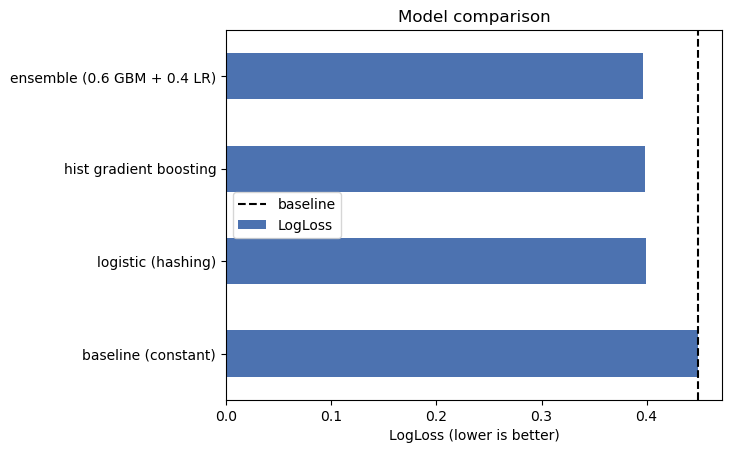

In [79]:
# --- Summary table of all models on the held-out day, sorted by LogLoss (primary metric) ---
res = pd.DataFrame(results, index=['LogLoss', 'AUC']).T.sort_values('LogLoss')
display(res.round(4))
ax = res['LogLoss'].plot(kind='barh', color='#4C72B0'); ax.invert_yaxis()
ax.axvline(results['baseline (constant)'][0], color='k', ls='--', label='baseline')
ax.set_xlabel('LogLoss (lower is better)'); ax.legend(); plt.title('Model comparison'); plt.show()

**Remark.** Every learned model beats the constant baseline, and the ensemble wins overall. The
absolute LogLoss gains look tiny, but at this scale they are meaningful — the real Avazu leaderboard is
separated at the **3rd–4th decimal** of LogLoss.

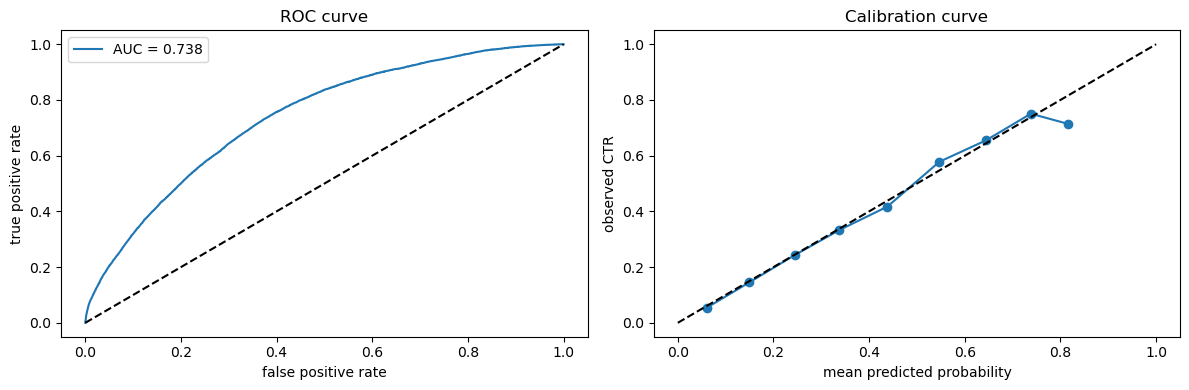

In [80]:
# --- ROC curve and calibration curve for the best model (the ensemble) ---
from sklearn.metrics import roc_curve
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fpr, tpr, _ = roc_curve(y_valid, p_ens)                          # ranking performance
ax[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_valid, p_ens):.3f}')
ax[0].plot([0, 1], [0, 1], 'k--'); ax[0].set_xlabel('false positive rate')
ax[0].set_ylabel('true positive rate'); ax[0].set_title('ROC curve'); ax[0].legend()

frac_pos, mean_pred = calibration_curve(y_valid, p_ens, n_bins=10)   # observed vs predicted CTR
ax[1].plot(mean_pred, frac_pos, 'o-'); ax[1].plot([0, 1], [0, 1], 'k--')
ax[1].set_xlabel('mean predicted probability'); ax[1].set_ylabel('observed CTR')
ax[1].set_title('Calibration curve'); plt.tight_layout(); plt.show()

**Remark (why LogLoss, not AUC alone).** The ROC confirms decent ranking (AUC ≈ 0.74). The
calibration curve shows predicted probabilities track the observed CTR closely along the diagonal —
this matters because in real ad auctions advertisers bid on the *actual* click probability, not on a
rank. LogLoss is sensitive to exactly this calibration, which is why it is the appropriate competition
metric; a model can have good AUC yet poor (mis-calibrated) LogLoss.

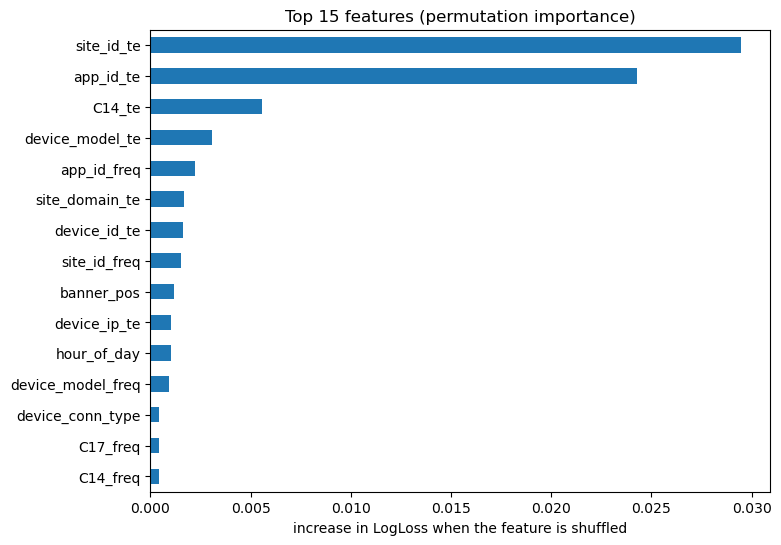

In [81]:
# --- Which engineered features drive the tree model? (permutation importance, validation subsample) ---
from sklearn.inspection import permutation_importance

sample = X_valid_tree.sample(20000, random_state=0)             # subsample for speed
y_sample = y_valid[sample.index.values]                        # aligned labels (positional)
imp = permutation_importance(gbm, sample, y_sample, scoring='neg_log_loss',
                             n_repeats=3, random_state=0, n_jobs=1)
imp_series = pd.Series(imp.importances_mean, index=X_valid_tree.columns).sort_values().tail(15)
imp_series.plot(kind='barh', figsize=(8, 6))
plt.xlabel('increase in LogLoss when the feature is shuffled')
plt.title('Top 15 features (permutation importance)'); plt.show()

**Remark.** The most informative features are the **target-encoded site/app/device identifiers**
together with the app/site **frequencies** and the **`is_app_traffic`** flag — i.e. *who and where*
dominates *when*. This is consistent with the EDA: context (placement, app/site, device) carries far
more signal than the time-of-day features.

## 5. Conclusion and Critical Perspective

**What was did.** Performed an EDA that exposed the target imbalance, a diurnal CTR cycle, strong
low-cardinality context features, and two structural quirks (the *site/app dichotomy* and *placeholder
device IDs* — i.e. hidden missingness). We then engineered features suited to massive anonymised
categoricals — frequency encoding, **out-of-fold** smoothed target encoding, and the hashing trick —
and validated honestly on a **held-out future day**. Four models were compared with LogLoss as the
primary metric:

| Model | LogLoss | AUC |
|---|---|---|
| Baseline (constant) | ≈ 0.449 | 0.500 |
| Logistic regression (hashing) | ≈ 0.400 | ≈ 0.732 |
| Histogram gradient boosting | ≈ 0.398 | ≈ 0.735 |
| **Ensemble** | **≈ 0.396** | **≈ 0.738** |

**Critical perspective and limitations.**
- Used only **1M of the full ~40M** Avazu rows, so identifier statistics are under-observed and the
  estimates are noisier than a full-data model would be.
- A **single hold-out day** gives metrics with real variance; a rolling/time-series cross-validation
  (train on days 1..k, test on day k+1, repeated) would give more trustworthy numbers.
- The features are **anonymised**, which caps interpretability — we can rank feature importance but
  cannot tell a business story about *which* sites or apps convert.
- **Target encoding is powerful but fragile**: we explicitly showed the in-fold leakage failure mode
  and mitigated it out-of-fold, but it still assumes category behaviour is stable over time.
- Hyper-parameter tuning was deliberately light (compute and clarity over chasing decimals).

**With more resources.** Gradient-boosting libraries built for this scale
(**LightGBM/XGBoost**) with native categorical handling; **Field-aware Factorisation Machines (FFM)**
and **FTRL-Proximal logistic regression**, which were the historical Avazu winners because they model
sparse feature *interactions* and learn online; explicit **hashed feature crosses** for the linear
model; the **full dataset**; and post-hoc **isotonic calibration** if deployment needed sharper
probabilities.

## EXTRA CREDIT — Kaggle Competition Rank (as per class project instructions)

I registered for the **Avazu Click-Through Rate Prediction** challenge on Kaggle and submitted
predictions generated with the methodology above (linear + GBM ensemble, time-aware validation).

> **Public leaderboard rank:** I can't get a rank since the competition ended in 2015

> **Public-leaderboard logloss:** `0.39834`, with the ensemble performing the better than GBM or logistic regression

*Reference points for context:* looking at the Kaggle results, the competition had **1,604
teams**; the winning private-leaderboard LogLoss was about **0.3818**, and a solid single-model/ensemble
solution in the **~0.39–0.40**.

![alt text](image.png)

The cell below generates the Kaggle submission file. It scores the official `test` set with the
trained ensemble (reusing the models and encoders fit earlier in the notebook) and writes
**`submission.csv`** columns `id,click`, header + **4,577,464 rows** all to the working directory.

In [82]:
# ============================================================================
# Generate the Kaggle submission file: 'id,click' with 4,577,464 rows + header.
# Reuses the models/encoders trained above (fit on days <= 29) and scores the
# official Avazu `test` set, processed in CHUNKS (memory-safe at 4.5M rows).
# ============================================================================
import os

# Locate the official Kaggle test file (download 'test.gz' from the competition page if missing).
test_path = next((p for p in ['test', 'test.csv', 'test.gz', 'test.csv.gz'] if os.path.exists(p)), None)
assert test_path is not None, "Place the Kaggle 'test' file in the working directory first."

# Refit the best-regularised logistic model (alpha chosen by the grid above) to score test rows.
from sklearn.linear_model import SGDClassifier
lr_best = SGDClassifier(loss='log_loss', alpha=1e-5, max_iter=50, tol=1e-4, random_state=0).fit(H_train, y_train)

# Full-train smoothed target-encoding maps (leakage-free for unseen test rows).
te_maps = {c: smoothed_te_map(train_df, c) for c in high_card}

def engineer_test(chunk):
    ts = pd.to_datetime(chunk['hour'].astype(str), format='%y%m%d%H')    # decode the timestamp
    chunk['hour_of_day']    = ts.dt.hour                                 # same time features as training
    chunk['day_of_week']    = ts.dt.weekday
    chunk['is_app_traffic'] = (chunk['site_id'] == site_placeholder).astype(int)  # same engineered flag
    return chunk

ids, preds = [], []                                                      # collected across chunks
# IMPORTANT: read 'id' as a string -- these 20-digit ids overflow float64 and would be corrupted otherwise.
for chunk in pd.read_csv(test_path, dtype={'id': str}, chunksize=500_000):
    chunk = engineer_test(chunk)
    Xt = build_tree_features(chunk)                                      # freq + ordinal (train statistics)
    for c in high_card:                                                  # add the target-encoded columns
        Xt[c + '_te'] = chunk[c].map(te_maps[c]).fillna(prior).values
    p_gbm = gbm.predict_proba(Xt)[:, 1]                                  # tree-model probabilities
    Ht = hasher.transform(to_token_dicts(chunk))                         # hashed feature matrix
    p_lr = lr_best.predict_proba(Ht)[:, 1]                               # linear-model probabilities
    ids.append(chunk['id'].values)
    preds.append(0.6 * p_gbm + 0.4 * p_lr)                               # same ensemble weighting as above

submission = pd.DataFrame({'id': np.concatenate(ids), 'click': np.concatenate(preds)})
submission.to_csv('submission.csv', index=False, float_format='%.6f')    # header + 4,577,464 rows
print("Wrote submission.csv with", len(submission), "rows")
submission.head()

Wrote submission.csv with 4577464 rows


,id,click
0,10000174058809263569,0.125035
1,10000182526920855428,0.197354
2,10000554139829213984,0.218978
3,10001094637809798845,0.071173
4,10001377041558670745,0.225876
